<a href="https://colab.research.google.com/github/dapedeje/TFG/blob/main/ModeloComplejo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="FF3B3B"><h1 align="left">Sistema multimodal para la detección e identificación de especies de hongos mediante visión por computador y modelos de lenguaje</h1></font>
<font color="#6E6E6E"><h2 align="left">Entrenamiento del modelo complejo</h2></font>

#### David Alejandro Pedroza De Jesús

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import os
import tensorflow as tf
from google.colab import drive
from tensorflow.keras import layers, models
import shutil
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from keras.utils import plot_model

In [2]:
drive.mount('/content/drive/')
shutil.copy("/content/drive/MyDrive/kaggle.zip","/content/")
!unzip kaggle.zip
shutil.copy("/content/drive/MyDrive/InfoEspecies.csv","/content/")

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39104medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39105medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39106medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39107medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39108medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39109medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39110medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39111medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39112medium.jpg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39113medium.jpeg  
  inflating: kaggle/working/merged_dataset/Xanthoria parietina/39114medium.jpg  
  inflating: kaggle/working/merged_dataset/

'/content/InfoEspecies.csv'

# Carga de los datos

In [3]:
rutas_val = pd.read_csv("kaggle/working/val.csv")
rutas_train = pd.read_csv("kaggle/working/train.csv")
rutas_test = pd.read_csv("kaggle/working/test.csv")
info_especies = pd.read_csv("InfoEspecies.csv")
info_especies = info_especies.drop(info_especies.columns[0], axis= "columns")

train = pd.merge(info_especies, rutas_train, on='label', how='inner')
test = pd.merge(info_especies, rutas_test, on='label', how='inner')
val = pd.merge(info_especies, rutas_val, on='label', how='inner')

In [4]:

def ArreglarLasRutas(df):
    rutas_nuevas = []
    for path in df.image_path:
        path = path.lstrip("/")
        rutas_nuevas.append(path)
    df.image_path = rutas_nuevas

def Modificar_direc(df_rutas, subset):
    os.makedirs(f"Data/{subset}", exist_ok=True)

    ArreglarLasRutas(df_rutas)

    for path, label in zip(df_rutas.image_path, df_rutas.label):
        destino = f"Data/{subset}/{label}/"
        os.makedirs(destino, exist_ok=True)
        print(f"Copiando {path} --> {destino}")
        shutil.copy(path, destino)
        print(f"Terminado {label}")

In [5]:
Modificar_direc(train, "train")
Modificar_direc(test, "test")
Modificar_direc(val, "valid")

Se han truncado las últimas 5000 líneas del flujo de salida.
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23452medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/22011medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/20680medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/21100medium.jpg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/19837medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/23382medium.jpeg --> Data/valid/Fomitopsis pinicola/
Terminado Fomitopsis pinicola
Copiando kaggle/working/merged_dataset/Fomitopsis pinicola/19047medium.jpeg --> Data/val

In [10]:
train_dir = "Data/train"
test_dir = "Data/test"
val_dir = "Data/valid"


train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(64, 64),
    batch_size=128,
    label_mode='int'
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(64, 64),
    batch_size=128,
    label_mode='int'
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(64, 64),
    batch_size=128,
    label_mode='int'
)

normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))
valid_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Found 30068 files belonging to 54 classes.
Found 6442 files belonging to 54 classes.
Found 6443 files belonging to 54 classes.


# Creamos el modelo

In [11]:
num_classes = 57


model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds, epochs=60, validation_data=valid_ds)

test_loss, test_acc = model.evaluate(test_ds)
print(f"Precisión en test: {test_acc:.4f}")

Epoch 1/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 79s 316ms/step - accuracy: 0.2417 - loss: 3.1368 - val_accuracy: 0.3267 - val_loss: 2.7139
Epoch 2/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 267ms/step - accuracy: 0.3690 - loss: 2.4440 - val_accuracy: 0.3970 - val_loss: 2.3176
Epoch 3/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 269ms/step - accuracy: 0.4287 - loss: 2.1549 - val_accuracy: 0.4364 - val_loss: 2.1407
Epoch 4/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 268ms/step - accuracy: 0.4615 - loss: 1.9899 - val_accuracy: 0.4489 - val_loss: 2.0706
Epoch 5/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 64s 271ms/step - accuracy: 0.4957 - loss: 1.8539 - val_accuracy: 0.4669 - val_loss: 2.0030
Epoch 6/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 270ms/step - accuracy: 0.5196 - loss: 1.7441 - val_accuracy: 0.4836 - val_loss: 1.9239
Epoch 7/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 273ms/step - accuracy: 0.5481 - loss: 1.6326 - val_accuracy: 0.4842 - val_loss: 1.9190
Epoch 8/60
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 316ms/step - accuracy: 0.5676 - loss: 1

# Arquitectura del modelo

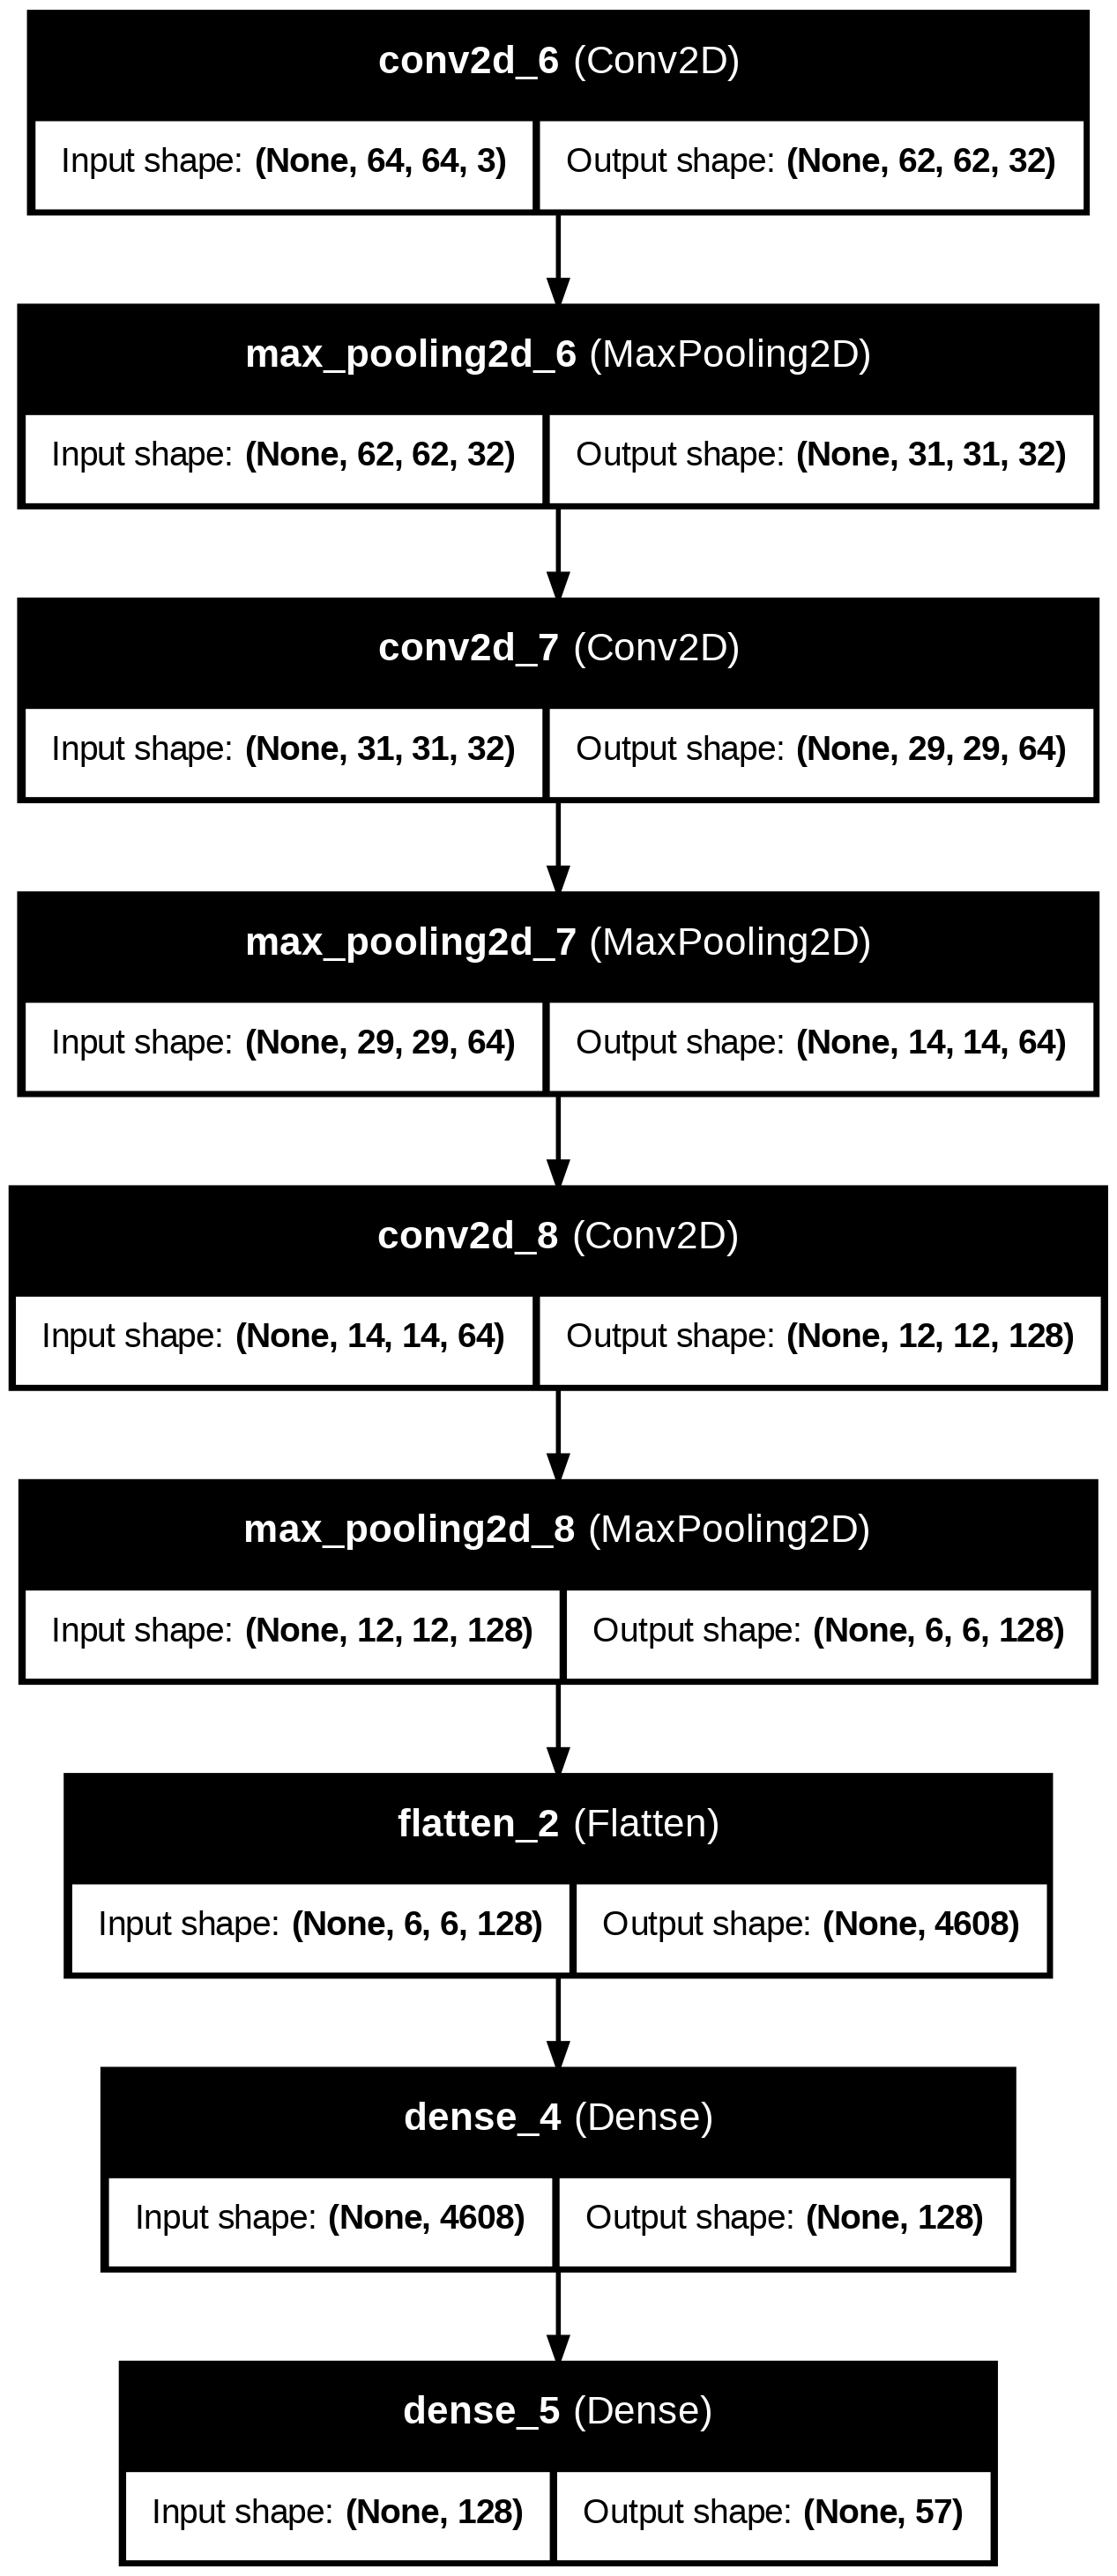

In [12]:
plot_model(model, to_file='modelo.png', show_shapes=True, show_layer_names=True)

# graficos error

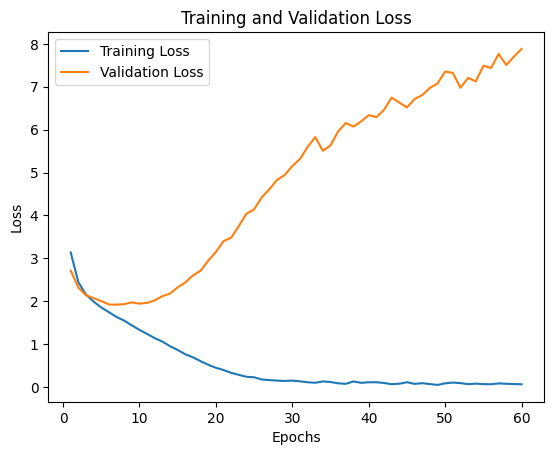

In [14]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(list(range(1,61)),train_loss, label='Training Loss')
plt.plot(list(range(1,61)),val_loss,label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

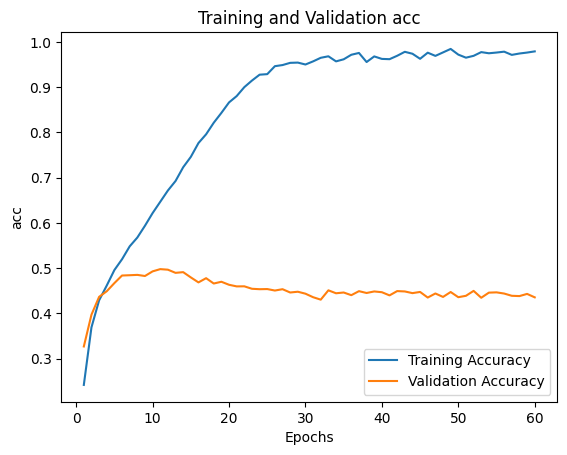

In [18]:
val_acc = history.history['val_accuracy']
train_acc = history.history['accuracy']
plt.plot(list(range(1,61)),train_acc, label='Training Accuracy')
plt.plot(list(range(1,61)),val_acc,label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation acc')
plt.xlabel('Epochs')
plt.ylabel('acc')
plt.show()

# matriz de confusión

In [15]:
# Inicializar listas
y_true = []
y_pred = []

# Iterar sobre el dataset de prueba
for images, labels in test_ds:
    y_true.extend(labels.numpy())                        # Labels reales
    preds = model.predict(images)                        # Predicciones del modelo
    y_pred.extend(np.argmax(preds, axis=1))              # Clase con mayor probabilidad

# Convertir a arrays de numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
4/4 ━━━━━━━━

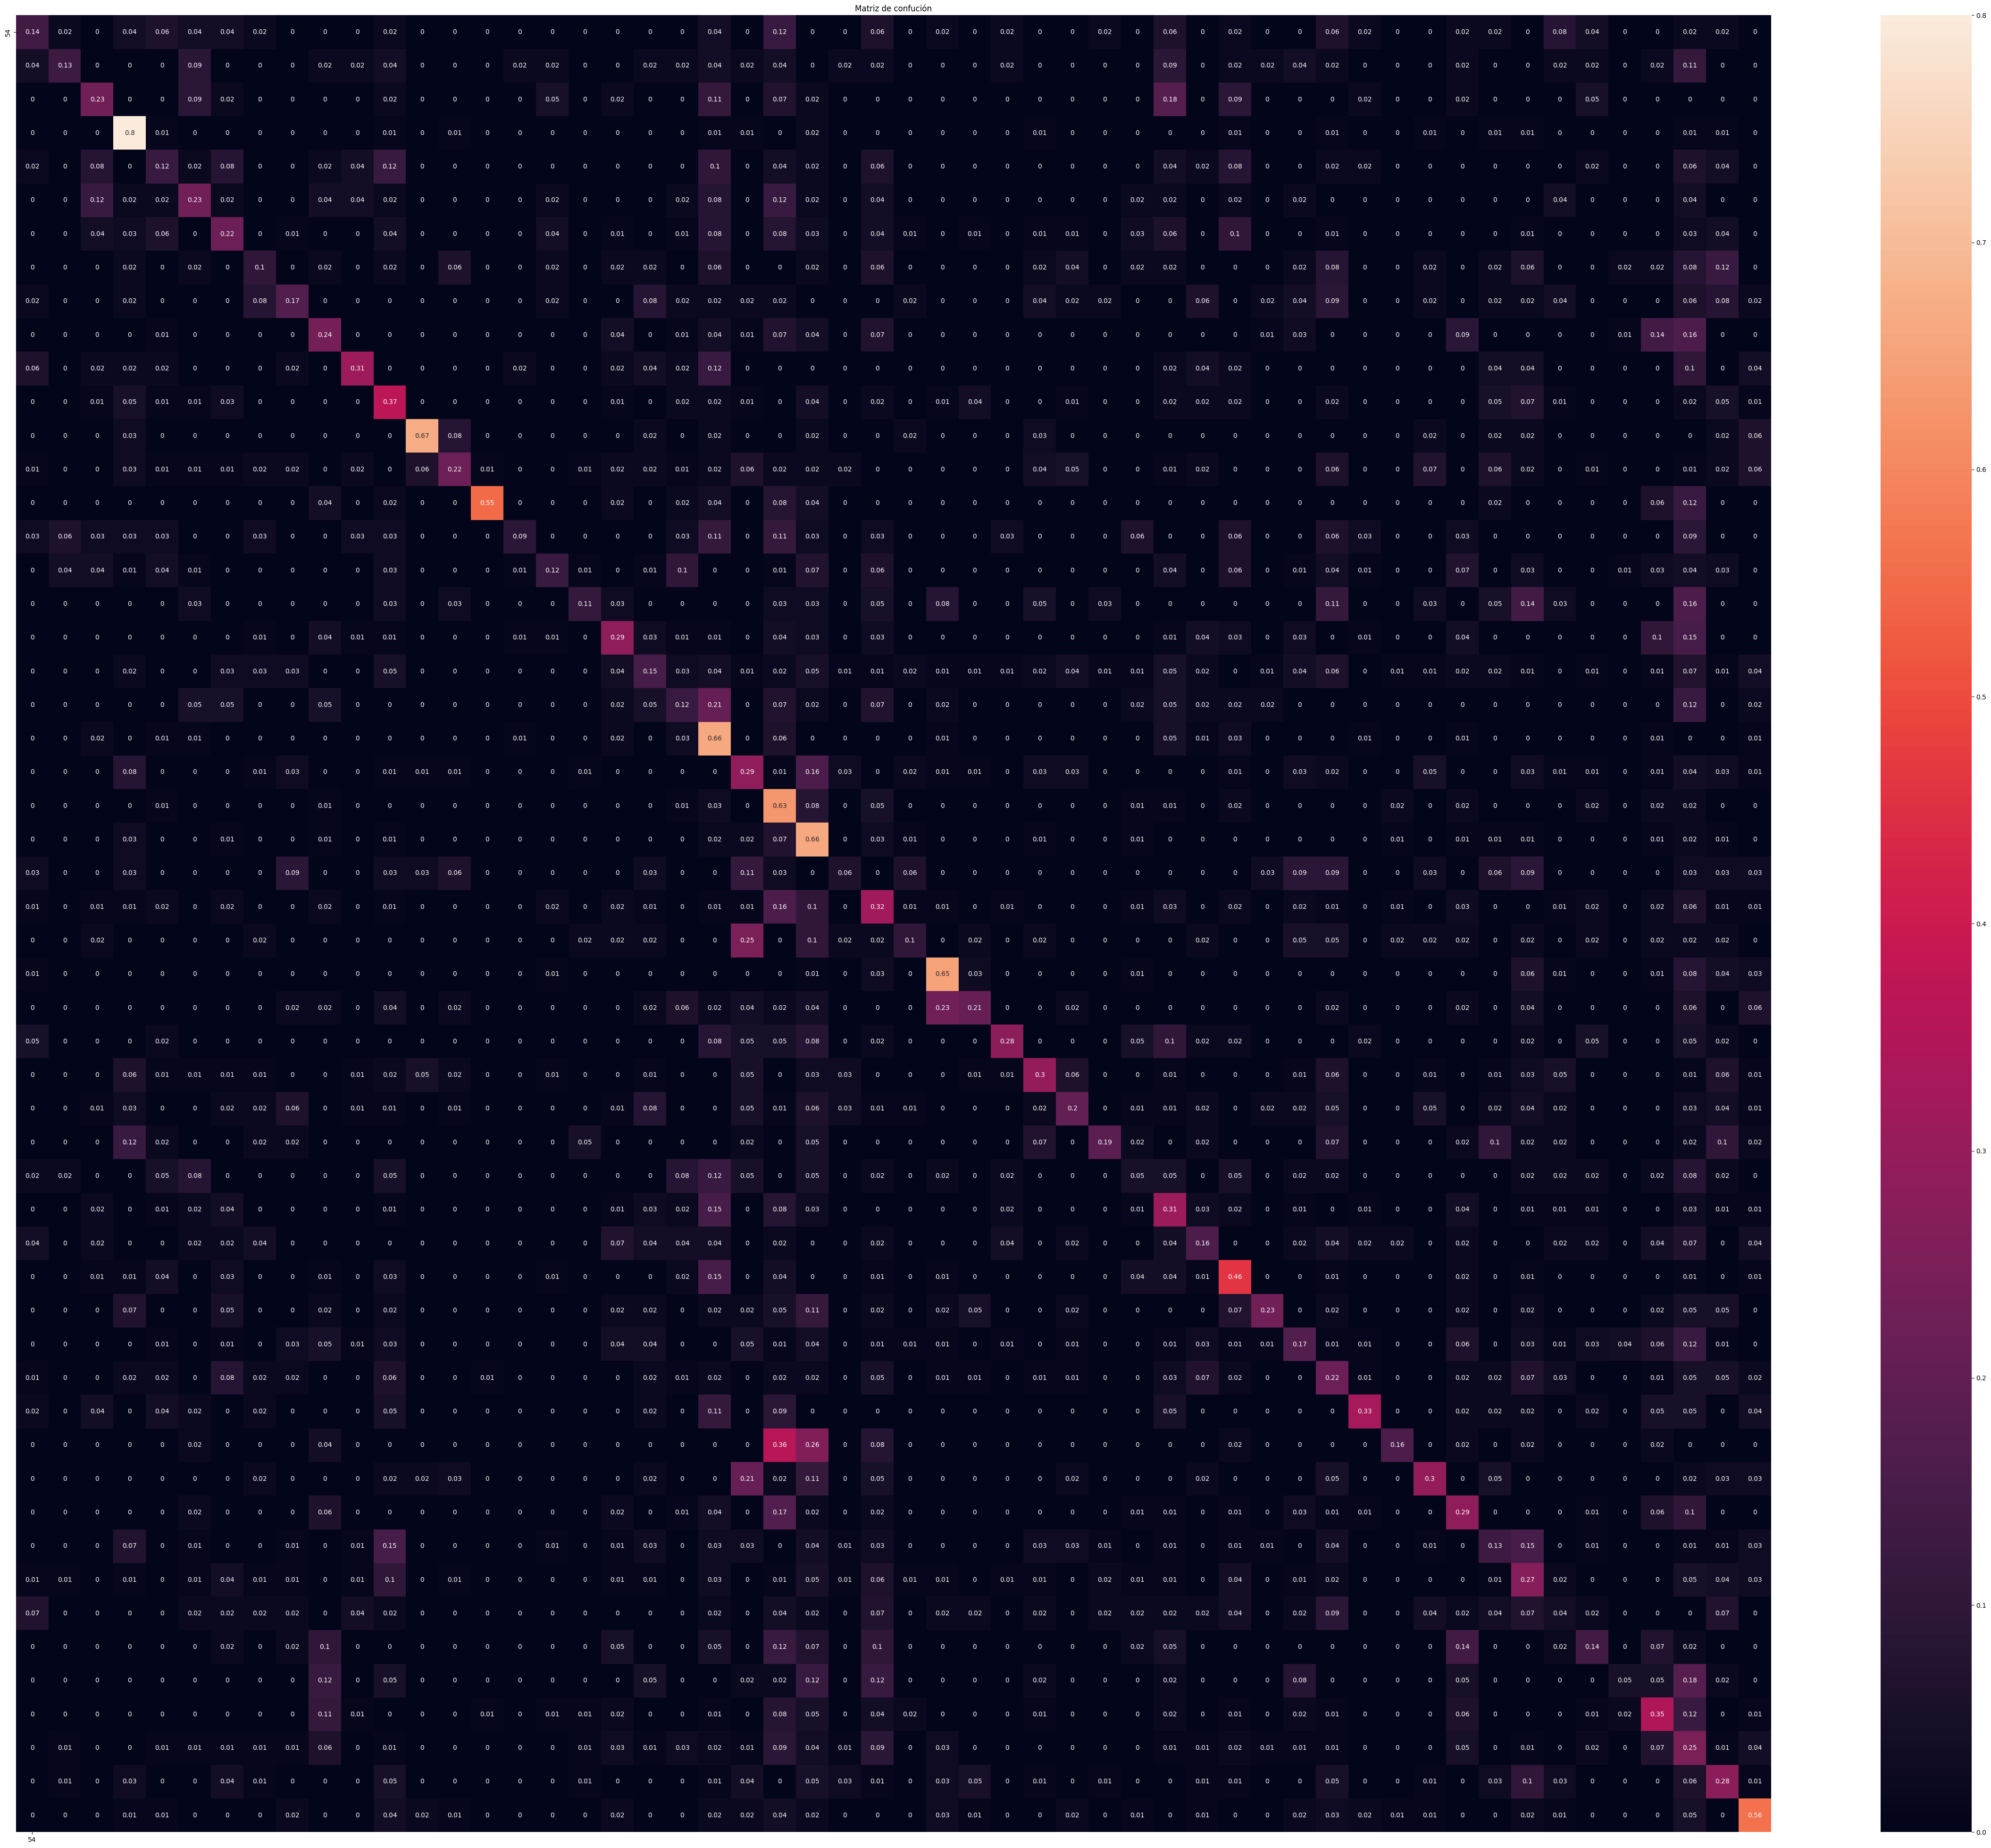

In [16]:
cm = confusion_matrix(y_true,y_pred ,normalize= "true").round(2)
plt.subplots(figsize=(60,50))
sns.heatmap(cm,xticklabels= info_especies.label.shape, yticklabels=info_especies.label.shape,annot=True)
plt.title("Matriz de confución")
plt.show()

In [17]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.19      0.14      0.16        51
           1       0.30      0.13      0.18        46
           2       0.20      0.23      0.21        44
           3       0.85      0.80      0.83       687
           4       0.10      0.12      0.11        51
           5       0.19      0.23      0.21        48
           6       0.18      0.22      0.20        79
           7       0.13      0.10      0.11        49
           8       0.20      0.17      0.19        53
           9       0.17      0.24      0.20        70
          10       0.38      0.31      0.34        48
          11       0.42      0.37      0.39       220
          12       0.66      0.67      0.66        63
          13       0.51      0.22      0.31       126
          14       0.85      0.55      0.67        51
          15       0.27      0.09      0.13        35
          16       0.26      0.12      0.16        68
          17       0.21    